In [3]:
import os
import pandas as pd

# RAF-DB dataset root
train_root = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
test_root  = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"

# RAF-DB folders: 1 to 7
class_folders = ['1', '2', '3', '4', '5', '6', '7']

# Folder mapping to labels 0 to 6
label_map = {folder: idx for idx, folder in enumerate(class_folders)}

all_data = []

# Collect original train images
for folder in class_folders:
    folder_path = os.path.join(train_root, folder)

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        if image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            all_data.append([image_path, label_map[folder]])

# Collect original test images
for folder in class_folders:
    folder_path = os.path.join(test_root, folder)

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        if image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            all_data.append([image_path, label_map[folder]])

# Full dataframe
df = pd.DataFrame(all_data, columns=["image_path", "label"])

print("Full RAF-DB dataframe created")
print("Total images:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
print(df.head())

Full RAF-DB dataframe created
Total images: 15339

Class distribution:
label
0    1619
1     355
2     877
3    5957
4    2460
5     867
6    3204
Name: count, dtype: int64

First 5 rows:
                                          image_path  label
0  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
1  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
2  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
3  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
4  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0


In [4]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =========================
# 50:50 stratified split
# =========================
train_df_50, test_df_50 = train_test_split(
    df,
    test_size=0.50,
    stratify=df["label"],
    random_state=SEED
)

train_df_50 = train_df_50.reset_index(drop=True)
test_df_50 = test_df_50.reset_index(drop=True)

print("Total images :", len(df))
print("Train size   :", len(train_df_50))
print("Test size    :", len(test_df_50))

print("\nTrain class distribution:")
print(train_df_50["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df_50["label"].value_counts().sort_index())

Total images : 15339
Train size   : 7669
Test size    : 7670

Train class distribution:
label
0     809
1     178
2     438
3    2978
4    1230
5     434
6    1602
Name: count, dtype: int64

Test class distribution:
label
0     810
1     177
2     439
3    2979
4    1230
5     433
6    1602
Name: count, dtype: int64


In [5]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class RAFDBDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# CNN / ResNet input size: 96 x 96
cnn_train_transform_50 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

cnn_test_transform_50 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# Keep separate names even if ResNet uses same image size
resnet_train_transform_50 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

resnet_test_transform_50 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# EfficientNet input size: 224 x 224
eff_train_transform_50 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

eff_test_transform_50 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

# CNN datasets/loaders
cnn_train_dataset_50 = RAFDBDataset(train_df_50, cnn_train_transform_50)
cnn_test_dataset_50 = RAFDBDataset(test_df_50, cnn_test_transform_50)

cnn_train_loader_50 = DataLoader(
    cnn_train_dataset_50, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
cnn_test_loader_50 = DataLoader(
    cnn_test_dataset_50, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# ResNet datasets/loaders
resnet_train_dataset_50 = RAFDBDataset(train_df_50, resnet_train_transform_50)
resnet_test_dataset_50 = RAFDBDataset(test_df_50, resnet_test_transform_50)

resnet_train_loader_50 = DataLoader(
    resnet_train_dataset_50, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
resnet_test_loader_50 = DataLoader(
    resnet_test_dataset_50, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# EfficientNet datasets/loaders
eff_train_dataset_50 = RAFDBDataset(train_df_50, eff_train_transform_50)
eff_test_dataset_50 = RAFDBDataset(test_df_50, eff_test_transform_50)

eff_train_loader_50 = DataLoader(
    eff_train_dataset_50, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
eff_test_loader_50 = DataLoader(
    eff_test_dataset_50, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print("CNN Train/Test:", len(cnn_train_dataset_50), len(cnn_test_dataset_50))
print("ResNet Train/Test:", len(resnet_train_dataset_50), len(resnet_test_dataset_50))
print("EfficientNet Train/Test:", len(eff_train_dataset_50), len(eff_test_dataset_50))

Device: cuda
CNN Train/Test: 7669 7670
ResNet Train/Test: 7669 7670
EfficientNet Train/Test: 7669 7670


In [6]:
images, labels = next(iter(cnn_train_loader_50))

print("CNN batch image shape:", images.shape)
print("CNN batch label shape:", labels.shape)
print("First 10 labels:", labels[:10].tolist())

CNN batch image shape: torch.Size([64, 3, 96, 96])
CNN batch label shape: torch.Size([64])
First 10 labels: [0, 3, 5, 3, 3, 3, 5, 3, 6, 3]


In [7]:
import torch
import torch.nn as nn

class CustomCNN50(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN50, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

cnn_model_50 = CustomCNN50(num_classes=7).to(device)

print(cnn_model_50)

CustomCNN50(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion_cnn_50 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_cnn_50 = optim.Adam(
    cnn_model_50.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler_cnn_50 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn_50,
    T_max=80
)

# =========================
# Early stopping class
# =========================
class EarlyStoppingCNN50:
    def __init__(self, patience=10):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs_cnn_50 = 80
early_stopping_cnn_50 = EarlyStoppingCNN50(patience=10)

cnn50_train_acc_list = []
cnn50_test_acc_list = []
cnn50_train_loss_list = []
cnn50_test_loss_list = []

best_cnn50_test_acc = 0.0

# =========================
# Training loop
# =========================
for epoch in range(epochs_cnn_50):

    # ---------- TRAIN ----------
    cnn_model_50.train()
    running_train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in cnn_train_loader_50:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_cnn_50.zero_grad()

        outputs = cnn_model_50(images)
        loss = criterion_cnn_50(outputs, labels)

        loss.backward()
        optimizer_cnn_50.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(cnn_train_loader_50)

    # ---------- TEST ----------
    cnn_model_50.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in cnn_test_loader_50:
            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model_50(images)
            loss = criterion_cnn_50(outputs, labels)

            running_test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(cnn_test_loader_50)

    scheduler_cnn_50.step()

    # Save best model based on test accuracy
    if test_acc > best_cnn50_test_acc:
        best_cnn50_test_acc = test_acc
        torch.save(
            cnn_model_50.state_dict(),
            "/kaggle/working/best_cnn_50_50.pth"
        )

    cnn50_train_acc_list.append(train_acc)
    cnn50_test_acc_list.append(test_acc)
    cnn50_train_loss_list.append(train_loss)
    cnn50_test_loss_list.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs_cnn_50}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # Early stopping based on test accuracy
    early_stopping_cnn_50(test_acc)

    if early_stopping_cnn_50.stop:
        print("Early stopping triggered")
        break

print("Best CNN 50:50 Test Accuracy:", best_cnn50_test_acc)
print("Saved model: /kaggle/working/best_cnn_50_50.pth")

Epoch 1/80
Train Acc: 38.64 | Test Acc: 46.26
Train Loss: 1.8459 | Test Loss: 1.5703

Epoch 2/80
Train Acc: 45.61 | Test Acc: 50.94
Train Loss: 1.5884 | Test Loss: 1.4574

Epoch 3/80
Train Acc: 48.05 | Test Acc: 53.34
Train Loss: 1.5255 | Test Loss: 1.4178

Epoch 4/80
Train Acc: 49.64 | Test Acc: 53.34
Train Loss: 1.5007 | Test Loss: 1.3895

Epoch 5/80
Train Acc: 50.57 | Test Acc: 56.02
Train Loss: 1.4735 | Test Loss: 1.3444

Epoch 6/80
Train Acc: 51.74 | Test Acc: 57.44
Train Loss: 1.4429 | Test Loss: 1.3601

Epoch 7/80
Train Acc: 52.44 | Test Acc: 59.43
Train Loss: 1.4363 | Test Loss: 1.3254

Epoch 8/80
Train Acc: 53.14 | Test Acc: 61.64
Train Loss: 1.4175 | Test Loss: 1.3018

Epoch 9/80
Train Acc: 53.36 | Test Acc: 62.79
Train Loss: 1.4051 | Test Loss: 1.2741

Epoch 10/80
Train Acc: 55.81 | Test Acc: 63.02
Train Loss: 1.3772 | Test Loss: 1.2894

Epoch 11/80
Train Acc: 55.56 | Test Acc: 65.72
Train Loss: 1.3778 | Test Loss: 1.2345

Epoch 12/80
Train Acc: 57.01 | Test Acc: 67.52
Train

In [9]:
import numpy as np
import torch.nn.functional as F

# Load best saved CNN model
cnn_model_50.load_state_dict(
    torch.load("/kaggle/working/best_cnn_50_50.pth", map_location=device)
)
cnn_model_50.eval()

cnn_probs_50 = []
cnn_preds_50 = []
cnn_true_50 = []

with torch.no_grad():
    for images, labels in cnn_test_loader_50:
        images = images.to(device)

        outputs = cnn_model_50(images)
        probs = F.softmax(outputs, dim=1)

        cnn_probs_50.extend(probs.cpu().numpy())
        cnn_preds_50.extend(torch.argmax(probs, dim=1).cpu().numpy())
        cnn_true_50.extend(labels.numpy())

cnn_probs_50 = np.array(cnn_probs_50)
cnn_preds_50 = np.array(cnn_preds_50)
cnn_true_50 = np.array(cnn_true_50)

cnn_acc_50 = (cnn_preds_50 == cnn_true_50).mean() * 100

print("CNN probabilities shape :", cnn_probs_50.shape)
print("CNN predictions shape   :", cnn_preds_50.shape)
print("CNN true labels shape   :", cnn_true_50.shape)
print(f"CNN 50:50 Accuracy from saved model: {cnn_acc_50:.2f}%")

CNN probabilities shape : (7670, 7)
CNN predictions shape   : (7670,)
CNN true labels shape   : (7670,)
CNN 50:50 Accuracy from saved model: 76.71%


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Bottleneck50(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion,
            kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out += self.shortcut(x)
        out = F.relu(out)

        return out


class ResNet50Scratch50(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512 * Bottleneck50.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        strides = [stride] + [1] * (blocks - 1)
        layers = []

        for current_stride in strides:
            layers.append(
                Bottleneck50(
                    self.in_channels,
                    out_channels,
                    current_stride
                )
            )
            self.in_channels = out_channels * Bottleneck50.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.adaptive_avg_pool2d(x, 1)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)

        return x


resnet_model_50 = ResNet50Scratch50(num_classes=7).to(device)

print(resnet_model_50)

ResNet50Scratch50(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck50(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion_resnet_50 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_resnet_50 = optim.Adam(
    resnet_model_50.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_resnet_50 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_resnet_50,
    T_max=50
)

class EarlyStoppingResNet50:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

epochs_resnet_50 = 50
early_stopping_resnet_50 = EarlyStoppingResNet50(patience=8)

resnet50_train_acc_list = []
resnet50_test_acc_list = []
resnet50_train_loss_list = []
resnet50_test_loss_list = []

best_resnet50_test_acc = 0.0

for epoch in range(epochs_resnet_50):

    # TRAIN
    resnet_model_50.train()
    running_train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader_50:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet_50.zero_grad()

        outputs = resnet_model_50(images)
        loss = criterion_resnet_50(outputs, labels)

        loss.backward()
        optimizer_resnet_50.step()

        running_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(resnet_train_loader_50)

    # TEST
    resnet_model_50.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in resnet_test_loader_50:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model_50(images)
            loss = criterion_resnet_50(outputs, labels)

            running_test_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(resnet_test_loader_50)

    scheduler_resnet_50.step()

    if test_acc > best_resnet50_test_acc:
        best_resnet50_test_acc = test_acc
        torch.save(
            resnet_model_50.state_dict(),
            "/kaggle/working/best_resnet50_50_50.pth"
        )

    resnet50_train_acc_list.append(train_acc)
    resnet50_test_acc_list.append(test_acc)
    resnet50_train_loss_list.append(train_loss)
    resnet50_test_loss_list.append(test_loss)

    print(f"Epoch {epoch + 1}/{epochs_resnet_50}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    early_stopping_resnet_50(test_acc)

    if early_stopping_resnet_50.stop:
        print("Early stopping triggered")
        break

print("Best ResNet50 50:50 Test Accuracy:", best_resnet50_test_acc)
print("Saved model: /kaggle/working/best_resnet50_50_50.pth")

Epoch 1/50
Train Acc: 35.58 | Test Acc: 40.10
Train Loss: 1.8768 | Test Loss: 1.7026

Epoch 2/50
Train Acc: 39.57 | Test Acc: 46.02
Train Loss: 1.7666 | Test Loss: 1.6146

Epoch 3/50
Train Acc: 47.01 | Test Acc: 52.58
Train Loss: 1.6143 | Test Loss: 1.5051

Epoch 4/50
Train Acc: 51.39 | Test Acc: 54.76
Train Loss: 1.5191 | Test Loss: 1.4094

Epoch 5/50
Train Acc: 54.24 | Test Acc: 55.75
Train Loss: 1.4434 | Test Loss: 1.3910

Epoch 6/50
Train Acc: 58.43 | Test Acc: 58.47
Train Loss: 1.3708 | Test Loss: 1.3156

Epoch 7/50
Train Acc: 60.16 | Test Acc: 60.83
Train Loss: 1.3153 | Test Loss: 1.2823

Epoch 8/50
Train Acc: 62.47 | Test Acc: 62.03
Train Loss: 1.2506 | Test Loss: 1.2526

Epoch 9/50
Train Acc: 65.51 | Test Acc: 63.65
Train Loss: 1.1898 | Test Loss: 1.2176

Epoch 10/50
Train Acc: 67.99 | Test Acc: 64.29
Train Loss: 1.1463 | Test Loss: 1.2063

Epoch 11/50
Train Acc: 70.31 | Test Acc: 65.40
Train Loss: 1.1068 | Test Loss: 1.1909

Epoch 12/50
Train Acc: 72.13 | Test Acc: 66.56
Train

In [12]:
import numpy as np
import torch.nn.functional as F

resnet_model_50.load_state_dict(
    torch.load("/kaggle/working/best_resnet50_50_50.pth", map_location=device)
)
resnet_model_50.eval()

resnet_probs_50 = []
resnet_preds_50 = []
resnet_true_50 = []

with torch.no_grad():
    for images, labels in resnet_test_loader_50:
        images = images.to(device)

        outputs = resnet_model_50(images)
        probs = F.softmax(outputs, dim=1)

        resnet_probs_50.extend(probs.cpu().numpy())
        resnet_preds_50.extend(torch.argmax(probs, dim=1).cpu().numpy())
        resnet_true_50.extend(labels.numpy())

resnet_probs_50 = np.array(resnet_probs_50)
resnet_preds_50 = np.array(resnet_preds_50)
resnet_true_50 = np.array(resnet_true_50)

resnet_acc_50 = (resnet_preds_50 == resnet_true_50).mean() * 100

print("ResNet probabilities shape :", resnet_probs_50.shape)
print("ResNet predictions shape   :", resnet_preds_50.shape)
print("ResNet true labels shape   :", resnet_true_50.shape)
print(f"ResNet50 50:50 Accuracy from saved model: {resnet_acc_50:.2f}%")

ResNet probabilities shape : (7670, 7)
ResNet predictions shape   : (7670,)
ResNet true labels shape   : (7670,)
ResNet50 50:50 Accuracy from saved model: 70.91%


In [13]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

# Load EfficientNet-B0 architecture without pretrained weights
efficientnet_model_50 = efficientnet_b0(weights=None)

# Replace final classifier for 7 RAF-DB emotion classes
in_features = efficientnet_model_50.classifier[1].in_features

efficientnet_model_50.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 7)
)

efficientnet_model_50 = efficientnet_model_50.to(device)

print(efficientnet_model_50)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [15]:
import torch.optim as optim

criterion_eff_50 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff_50 = optim.Adam(
    efficientnet_model_50.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_eff_50 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff_50,
    mode="min",
    factor=0.5,
    patience=3
)

class EarlyStoppingEff50:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

epochs_eff_50 = 60
early_stopping_eff_50 = EarlyStoppingEff50(patience=8)

eff50_train_acc_list = []
eff50_test_acc_list = []
eff50_train_loss_list = []
eff50_test_loss_list = []

best_eff50_test_acc = 0.0

for epoch in range(epochs_eff_50):

    # TRAIN
    efficientnet_model_50.train()
    running_train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in eff_train_loader_50:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_eff_50.zero_grad()

        outputs = efficientnet_model_50(images)
        loss = criterion_eff_50(outputs, labels)

        loss.backward()
        optimizer_eff_50.step()

        running_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(eff_train_loader_50)

    # TEST
    efficientnet_model_50.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in eff_test_loader_50:
            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model_50(images)
            loss = criterion_eff_50(outputs, labels)

            running_test_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(eff_test_loader_50)

    # Reduce LR based on validation/test loss
    scheduler_eff_50.step(test_loss)

    if test_acc > best_eff50_test_acc:
        best_eff50_test_acc = test_acc
        torch.save(
            efficientnet_model_50.state_dict(),
            "/kaggle/working/best_efficientnet_50_50.pth"
        )

    eff50_train_acc_list.append(train_acc)
    eff50_test_acc_list.append(test_acc)
    eff50_train_loss_list.append(train_loss)
    eff50_test_loss_list.append(test_loss)

    print(f"Epoch {epoch + 1}/{epochs_eff_50}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    early_stopping_eff_50(test_acc)

    if early_stopping_eff_50.stop:
        print("Early stopping triggered")
        break

print("Best EfficientNet 50:50 Test Accuracy:", best_eff50_test_acc)
print("Saved model: /kaggle/working/best_efficientnet_50_50.pth")

Epoch 1/60
Train Acc: 41.61 | Test Acc: 43.10
Train Loss: 1.6317 | Test Loss: 1.6363

Epoch 2/60
Train Acc: 45.08 | Test Acc: 46.22
Train Loss: 1.5828 | Test Loss: 1.5528

Epoch 3/60
Train Acc: 47.78 | Test Acc: 48.70
Train Loss: 1.5382 | Test Loss: 1.5153

Epoch 4/60
Train Acc: 49.30 | Test Acc: 51.94
Train Loss: 1.4941 | Test Loss: 1.4454

Epoch 5/60
Train Acc: 51.91 | Test Acc: 51.07
Train Loss: 1.4494 | Test Loss: 1.4575

Epoch 6/60
Train Acc: 54.26 | Test Acc: 56.18
Train Loss: 1.4012 | Test Loss: 1.3777

Epoch 7/60
Train Acc: 56.59 | Test Acc: 58.45
Train Loss: 1.3584 | Test Loss: 1.3254

Epoch 8/60
Train Acc: 58.43 | Test Acc: 61.36
Train Loss: 1.3155 | Test Loss: 1.2695

Epoch 9/60
Train Acc: 60.96 | Test Acc: 61.63
Train Loss: 1.2666 | Test Loss: 1.2736

Epoch 10/60
Train Acc: 62.63 | Test Acc: 63.72
Train Loss: 1.2330 | Test Loss: 1.2274

Epoch 11/60
Train Acc: 64.77 | Test Acc: 65.65
Train Loss: 1.1885 | Test Loss: 1.1868

Epoch 12/60
Train Acc: 66.38 | Test Acc: 65.55
Train

In [16]:
import numpy as np
import torch.nn.functional as F

efficientnet_model_50.load_state_dict(
    torch.load("/kaggle/working/best_efficientnet_50_50.pth", map_location=device)
)
efficientnet_model_50.eval()

eff_probs_50 = []
eff_preds_50 = []
eff_true_50 = []

with torch.no_grad():
    for images, labels in eff_test_loader_50:
        images = images.to(device)

        outputs = efficientnet_model_50(images)
        probs = F.softmax(outputs, dim=1)

        eff_probs_50.extend(probs.cpu().numpy())
        eff_preds_50.extend(torch.argmax(probs, dim=1).cpu().numpy())
        eff_true_50.extend(labels.numpy())

eff_probs_50 = np.array(eff_probs_50)
eff_preds_50 = np.array(eff_preds_50)
eff_true_50 = np.array(eff_true_50)

eff_acc_50 = (eff_preds_50 == eff_true_50).mean() * 100

print("EfficientNet probabilities shape :", eff_probs_50.shape)
print("EfficientNet predictions shape   :", eff_preds_50.shape)
print("EfficientNet true labels shape   :", eff_true_50.shape)
print(f"EfficientNet 50:50 Accuracy from saved model: {eff_acc_50:.2f}%")

EfficientNet probabilities shape : (7670, 7)
EfficientNet predictions shape   : (7670,)
EfficientNet true labels shape   : (7670,)
EfficientNet 50:50 Accuracy from saved model: 72.82%


In [17]:
import numpy as np
import pandas as pd

# Safety check: all outputs must match the same test-image order
assert cnn_probs_50.shape == resnet_probs_50.shape == eff_probs_50.shape
assert np.array_equal(cnn_true_50, resnet_true_50)
assert np.array_equal(cnn_true_50, eff_true_50)

y_true_50 = cnn_true_50

def dst_fuse_two(prob_a, prob_b, eps=1e-12):
    """
    DST-style normalized agreement fusion for two softmax vectors.
    Input shape: (N, 7)
    Output shape: (N, 7)
    """
    agreement = prob_a * prob_b
    denominator = agreement.sum(axis=1, keepdims=True)

    # fallback if an extremely unlikely numerical issue occurs
    fused = np.divide(
        agreement,
        denominator + eps
    )

    return fused

# Pairwise fusion
cnn_resnet_dst_probs_50 = dst_fuse_two(cnn_probs_50, resnet_probs_50)
cnn_eff_dst_probs_50 = dst_fuse_two(cnn_probs_50, eff_probs_50)
resnet_eff_dst_probs_50 = dst_fuse_two(resnet_probs_50, eff_probs_50)

# Triple fusion: combine all three probability vectors
cnn_resnet_eff_dst_probs_50 = (
    cnn_probs_50 * resnet_probs_50 * eff_probs_50
)

cnn_resnet_eff_dst_probs_50 = (
    cnn_resnet_eff_dst_probs_50 /
    (cnn_resnet_eff_dst_probs_50.sum(axis=1, keepdims=True) + 1e-12)
)

# Predictions
cnn_resnet_dst_preds_50 = np.argmax(cnn_resnet_dst_probs_50, axis=1)
cnn_eff_dst_preds_50 = np.argmax(cnn_eff_dst_probs_50, axis=1)
resnet_eff_dst_preds_50 = np.argmax(resnet_eff_dst_probs_50, axis=1)
cnn_resnet_eff_dst_preds_50 = np.argmax(cnn_resnet_eff_dst_probs_50, axis=1)

# Accuracies
cnn_resnet_dst_acc_50 = (cnn_resnet_dst_preds_50 == y_true_50).mean() * 100
cnn_eff_dst_acc_50 = (cnn_eff_dst_preds_50 == y_true_50).mean() * 100
resnet_eff_dst_acc_50 = (resnet_eff_dst_preds_50 == y_true_50).mean() * 100
cnn_resnet_eff_dst_acc_50 = (
    (cnn_resnet_eff_dst_preds_50 == y_true_50).mean() * 100
)

print(f"CNN + ResNet50 DST Accuracy: {cnn_resnet_dst_acc_50:.2f}%")
print(f"CNN + EfficientNet DST Accuracy: {cnn_eff_dst_acc_50:.2f}%")
print(f"ResNet50 + EfficientNet DST Accuracy: {resnet_eff_dst_acc_50:.2f}%")
print(f"CNN + ResNet50 + EfficientNet DST Accuracy: {cnn_resnet_eff_dst_acc_50:.2f}%")

dst_results_50 = pd.DataFrame({
    "Fusion Model": [
        "CustomCNN + ResNet50 DST",
        "CustomCNN + EfficientNet DST",
        "ResNet50 + EfficientNet DST",
        "CustomCNN + ResNet50 + EfficientNet DST"
    ],
    "Accuracy (%)": [
        cnn_resnet_dst_acc_50,
        cnn_eff_dst_acc_50,
        resnet_eff_dst_acc_50,
        cnn_resnet_eff_dst_acc_50
    ]
}).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

print("\nDST Fusion Results — 50:50 Split")
print(dst_results_50)

CNN + ResNet50 DST Accuracy: 74.04%
CNN + EfficientNet DST Accuracy: 76.53%
ResNet50 + EfficientNet DST Accuracy: 74.55%
CNN + ResNet50 + EfficientNet DST Accuracy: 76.51%

DST Fusion Results — 50:50 Split
                              Fusion Model  Accuracy (%)
0             CustomCNN + EfficientNet DST     76.531943
1  CustomCNN + ResNet50 + EfficientNet DST     76.505867
2              ResNet50 + EfficientNet DST     74.550196
3                 CustomCNN + ResNet50 DST     74.041721


In [18]:
final_results_50 = pd.DataFrame({
    "Model": [
        "CustomCNN",
        "ResNet50",
        "EfficientNet",
        "CustomCNN + ResNet50 DST",
        "CustomCNN + EfficientNet DST",
        "ResNet50 + EfficientNet DST",
        "CustomCNN + ResNet50 + EfficientNet DST"
    ],
    "Accuracy (%)": [
        cnn_acc_50,
        resnet_acc_50,
        eff_acc_50,
        cnn_resnet_dst_acc_50,
        cnn_eff_dst_acc_50,
        resnet_eff_dst_acc_50,
        cnn_resnet_eff_dst_acc_50
    ]
})

final_results_50 = final_results_50.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

final_results_50["Accuracy (%)"] = final_results_50["Accuracy (%)"].round(2)

print("Final Model Comparison — RAF-DB 50:50 Split")
print(final_results_50)

final_results_50.to_csv(
    "/kaggle/working/final_results_50_50.csv",
    index=False
)

print("\nSaved: /kaggle/working/final_results_50_50.csv")

Final Model Comparison — RAF-DB 50:50 Split
                                     Model  Accuracy (%)
0                                CustomCNN         76.71
1             CustomCNN + EfficientNet DST         76.53
2  CustomCNN + ResNet50 + EfficientNet DST         76.51
3              ResNet50 + EfficientNet DST         74.55
4                 CustomCNN + ResNet50 DST         74.04
5                             EfficientNet         72.82
6                                 ResNet50         70.91

Saved: /kaggle/working/final_results_50_50.csv


In [20]:
y_true_50 = cnn_true_50
y_pred_50 = cnn_preds_50

In [21]:
from sklearn.metrics import classification_report

class_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

report_50 = classification_report(
    cnn_true_50,
    cnn_preds_50,
    target_names=class_names,
    digits=2
)

print("Classification Report — CustomCNN (RAF-DB 50:50 Split)\n")
print(report_50)

with open("/kaggle/working/classification_report_cnn_50_50.txt", "w") as f:
    f.write("Classification Report — CustomCNN (RAF-DB 50:50 Split)\n\n")
    f.write(report_50)

print("\nSaved: /kaggle/working/classification_report_cnn_50_50.txt")

Classification Report — CustomCNN (RAF-DB 50:50 Split)

              precision    recall  f1-score   support

    Surprise       0.77      0.78      0.78       810
        Fear       0.00      0.00      0.00       177
     Disgust       0.53      0.02      0.04       439
       Happy       0.87      0.93      0.90      2979
         Sad       0.69      0.71      0.70      1230
       Anger       0.63      0.64      0.63       433
     Neutral       0.68      0.82      0.74      1602

    accuracy                           0.77      7670
   macro avg       0.60      0.56      0.54      7670
weighted avg       0.74      0.77      0.74      7670


Saved: /kaggle/working/classification_report_cnn_50_50.txt


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


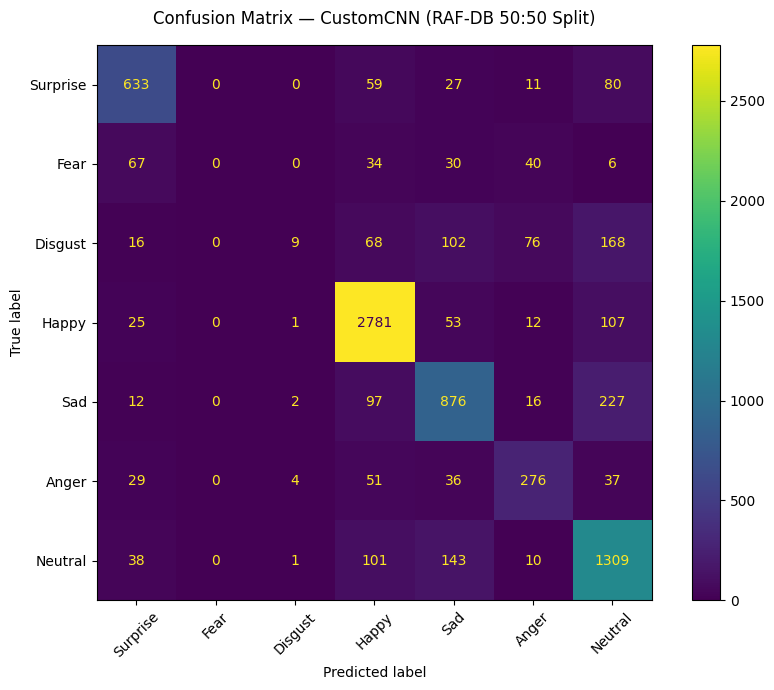

Saved: /kaggle/working/confusion_matrix_cnn_50_50.png


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_50 = confusion_matrix(cnn_true_50, cnn_preds_50)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_50,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Confusion Matrix — CustomCNN (RAF-DB 50:50 Split)", pad=15)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix_cnn_50_50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /kaggle/working/confusion_matrix_cnn_50_50.png")

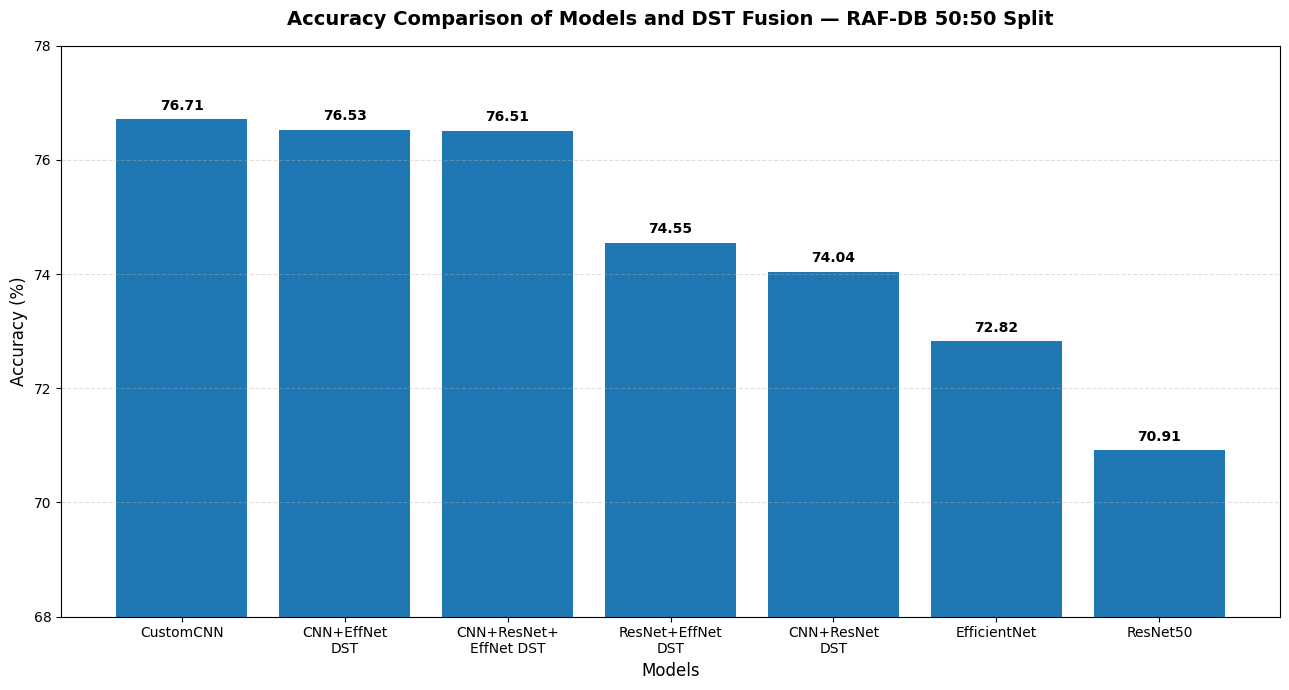

Saved: /kaggle/working/accuracy_comparison_50_50.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

plot_df_50 = final_results_50.copy()

# Short names for chart
short_names_50 = [
    "CustomCNN",
    "CNN+EffNet\nDST",
    "CNN+ResNet+\nEffNet DST",
    "ResNet+EffNet\nDST",
    "CNN+ResNet\nDST",
    "EfficientNet",
    "ResNet50"
]

accuracies_50 = plot_df_50["Accuracy (%)"].tolist()

best_idx_50 = int(np.argmax(accuracies_50))

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(short_names_50, accuracies_50)

# Add accuracy values
for bar, acc in zip(bars, accuracies_50):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.12,
        f"{acc:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Accuracy Comparison of Models and DST Fusion — RAF-DB 50:50 Split",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Models", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(68, 78)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/accuracy_comparison_50_50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /kaggle/working/accuracy_comparison_50_50.png")

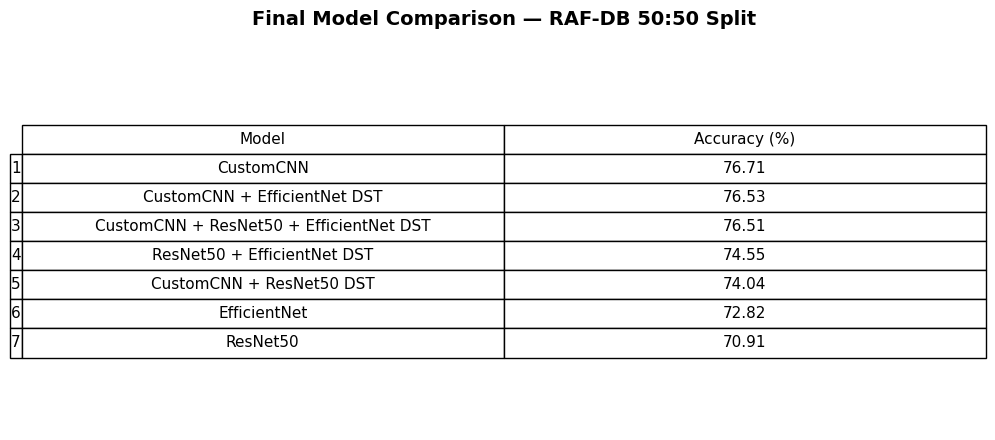

Saved: /kaggle/working/final_model_comparison_table_50_50.png


In [24]:
import matplotlib.pyplot as plt

report_table_50 = final_results_50.copy()
report_table_50.index = report_table_50.index + 1

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

table = ax.table(
    cellText=report_table_50.values,
    colLabels=report_table_50.columns,
    rowLabels=report_table_50.index,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

plt.title(
    "Final Model Comparison — RAF-DB 50:50 Split",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/final_model_comparison_table_50_50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: /kaggle/working/final_model_comparison_table_50_50.png")

Final Model Comparison — RAF-DB 50:50 Split
                                     Model  Accuracy (%)
1                                CustomCNN         76.71
2             CustomCNN + EfficientNet DST         76.53
3  CustomCNN + ResNet50 + EfficientNet DST         76.51
4              ResNet50 + EfficientNet DST         74.55
5                 CustomCNN + ResNet50 DST         74.04
6                             EfficientNet         72.82
7                                 ResNet50         70.91


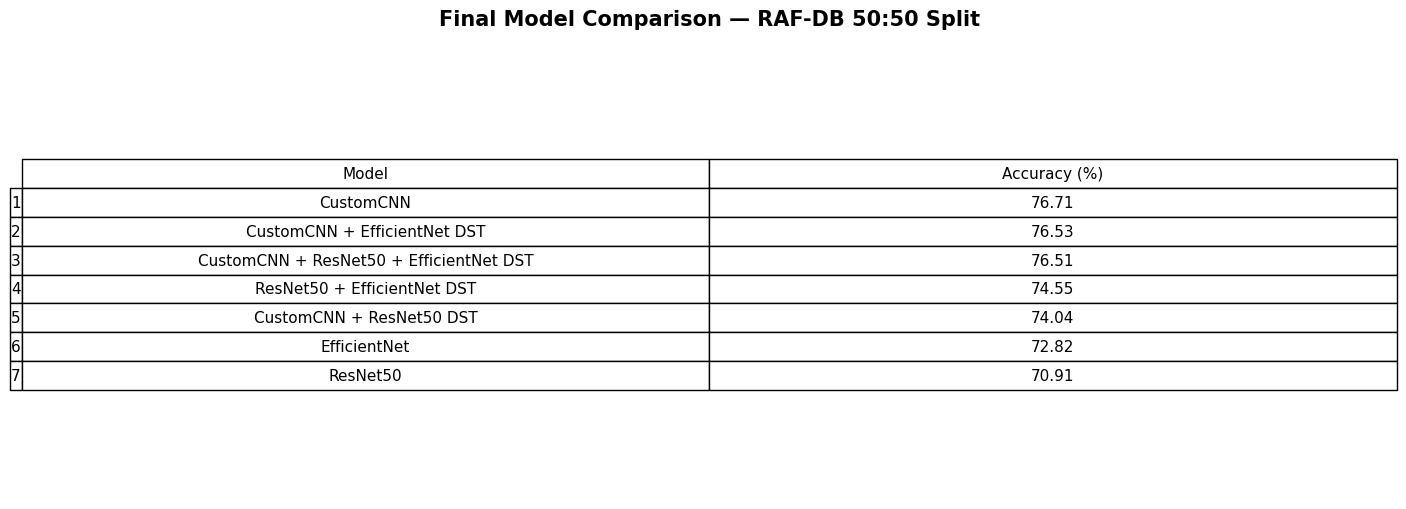


Saved image: /kaggle/working/final_model_comparison_50_50.png
Saved CSV: /kaggle/working/final_model_comparison_50_50.csv


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Original model and DST fusion results only
final_table_50 = pd.DataFrame({
    "Model": [
        "CustomCNN",
        "CustomCNN + EfficientNet DST",
        "CustomCNN + ResNet50 + EfficientNet DST",
        "ResNet50 + EfficientNet DST",
        "CustomCNN + ResNet50 DST",
        "EfficientNet",
        "ResNet50"
    ],
    "Accuracy (%)": [
        cnn_acc_50,
        cnn_eff_dst_acc_50,
        cnn_resnet_eff_dst_acc_50,
        resnet_eff_dst_acc_50,
        cnn_resnet_dst_acc_50,
        eff_acc_50,
        resnet_acc_50
    ]
})

# Sort by accuracy
final_table_50 = final_table_50.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

final_table_50["Accuracy (%)"] = final_table_50["Accuracy (%)"].round(2)

# Rank numbering 1, 2, 3...
final_table_50.index = final_table_50.index + 1

print("Final Model Comparison — RAF-DB 50:50 Split")
print(final_table_50)

# Create table image
fig, ax = plt.subplots(figsize=(14, 5.2))
ax.axis("off")

table = ax.table(
    cellText=final_table_50.values,
    colLabels=final_table_50.columns,
    rowLabels=final_table_50.index,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.15, 1.55)

plt.title(
    "Final Model Comparison — RAF-DB 50:50 Split",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/final_model_comparison_50_50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

final_table_50.to_csv(
    "/kaggle/working/final_model_comparison_50_50.csv",
    index=True
)

print("\nSaved image: /kaggle/working/final_model_comparison_50_50.png")
print("Saved CSV: /kaggle/working/final_model_comparison_50_50.csv")

In [50]:
import numpy as np
import pandas as pd

# ==========================================
# TRUE Exponent-Weighted DST Search
# ==========================================

y_true_50 = cnn_true_50
eps = 1e-12

weighted_dst_search_results = []

# CNN gets at least 0.40 because it is strongest.
# All weights sum to 1.0.
weight_values = np.arange(0.05, 1.00, 0.05)

for w_cnn in weight_values:
    for w_resnet in weight_values:
        w_eff = 1.0 - w_cnn - w_resnet

        if w_eff < 0.05:
            continue

        # TRUE weighted DST:
        # p_fused(class) ∝ p_cnn^w_cnn × p_resnet^w_resnet × p_eff^w_eff
        fused_probs = (
            (cnn_probs_50 + eps) ** w_cnn *
            (resnet_probs_50 + eps) ** w_resnet *
            (eff_probs_50 + eps) ** w_eff
        )

        fused_probs = fused_probs / (
            fused_probs.sum(axis=1, keepdims=True) + eps
        )

        fused_preds = np.argmax(fused_probs, axis=1)

        fused_acc = (fused_preds == y_true_50).mean() * 100

        weighted_dst_search_results.append([
            round(w_cnn, 2),
            round(w_resnet, 2),
            round(w_eff, 2),
            fused_acc
        ])

weighted_dst_search_df = pd.DataFrame(
    weighted_dst_search_results,
    columns=[
        "CustomCNN Weight",
        "ResNet50 Weight",
        "EfficientNet Weight",
        "Accuracy (%)"
    ]
)

weighted_dst_search_df = weighted_dst_search_df.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

weighted_dst_search_df["Accuracy (%)"] = (
    weighted_dst_search_df["Accuracy (%)"].round(2)
)

print("Top 20 TRUE Weighted DST configurations:\n")
print(weighted_dst_search_df.head(20))

weighted_dst_search_df.to_csv(
    "/kaggle/working/true_weighted_dst_search_50_50.csv",
    index=False
)

Top 20 TRUE Weighted DST configurations:

    CustomCNN Weight  ResNet50 Weight  EfficientNet Weight  Accuracy (%)
0               0.80             0.10                 0.10         78.51
1               0.75             0.10                 0.15         78.47
2               0.75             0.05                 0.20         78.47
3               0.80             0.05                 0.15         78.45
4               0.70             0.15                 0.15         78.41
5               0.75             0.15                 0.10         78.40
6               0.70             0.10                 0.20         78.36
7               0.85             0.05                 0.10         78.24
8               0.70             0.20                 0.10         78.16
9               0.70             0.05                 0.25         78.15
10              0.65             0.20                 0.15         78.10
11              0.65             0.15                 0.20         78.08
12       

In [51]:
best_weighted_dst_row_50 = weighted_dst_search_df.iloc[0]

best_w_cnn_dst = best_weighted_dst_row_50["CustomCNN Weight"]
best_w_resnet_dst = best_weighted_dst_row_50["ResNet50 Weight"]
best_w_eff_dst = best_weighted_dst_row_50["EfficientNet Weight"]

best_weighted_dst_probs_50 = (
    (cnn_probs_50 + eps) ** best_w_cnn_dst *
    (resnet_probs_50 + eps) ** best_w_resnet_dst *
    (eff_probs_50 + eps) ** best_w_eff_dst
)

best_weighted_dst_probs_50 = best_weighted_dst_probs_50 / (
    best_weighted_dst_probs_50.sum(axis=1, keepdims=True) + eps
)

best_weighted_dst_preds_50 = np.argmax(
    best_weighted_dst_probs_50,
    axis=1
)

best_weighted_dst_acc_50 = (
    best_weighted_dst_preds_50 == cnn_true_50
).mean() * 100

print("Best TRUE Weighted DST configuration:")
print(best_weighted_dst_row_50)

print(f"\nBest TRUE Weighted DST Accuracy: {best_weighted_dst_acc_50:.2f}%")
print(f"CustomCNN baseline Accuracy: {cnn_acc_50:.2f}%")

Best TRUE Weighted DST configuration:
CustomCNN Weight        0.80
ResNet50 Weight         0.10
EfficientNet Weight     0.10
Accuracy (%)           78.51
Name: 0, dtype: float64

Best TRUE Weighted DST Accuracy: 78.51%
CustomCNN baseline Accuracy: 76.71%


Complete Model and DST Comparison — RAF-DB 50:50 Split

                                                 Model  Accuracy (%)  \
Rank                                                                   
1     CustomCNN + ResNet50 + EfficientNet Weighted DST         78.51   
2                                            CustomCNN         76.71   
3                         CustomCNN + EfficientNet DST         76.53   
4                CustomCNN + EfficientNet Weighted DST         76.53   
5              CustomCNN + ResNet50 + EfficientNet DST         76.51   
6                 ResNet50 + EfficientNet Weighted DST         74.55   
7                          ResNet50 + EfficientNet DST         74.55   
8                             CustomCNN + ResNet50 DST         74.04   
9                    CustomCNN + ResNet50 Weighted DST         74.04   
10                                        EfficientNet         72.82   
11                                            ResNet50         70.91   

       

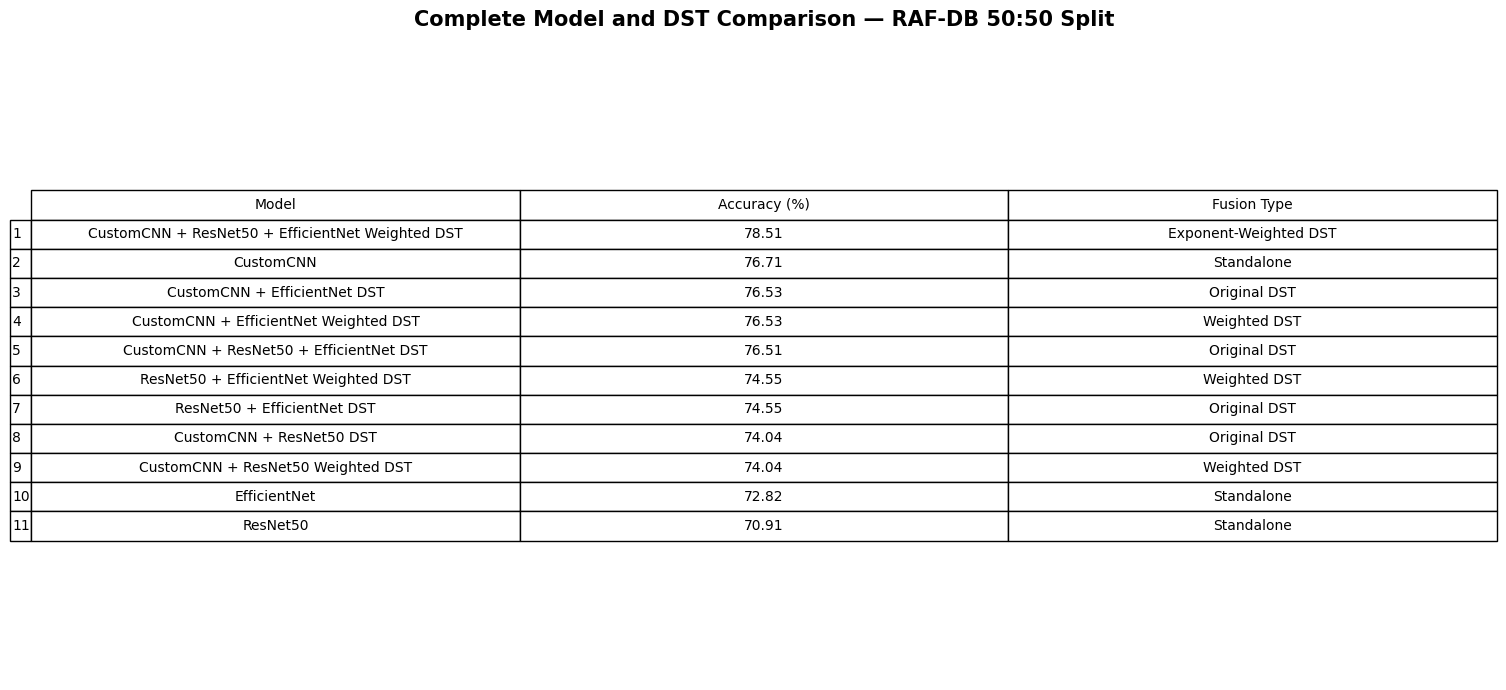


Saved CSV: /kaggle/working/all_results_50_50.csv
Saved image: /kaggle/working/all_results_table_50_50.png


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# All Results in One Table — RAF-DB 50:50
# ==========================================

all_results_50 = pd.DataFrame({
    "Model": [
        "CustomCNN",
        "ResNet50",
        "EfficientNet",

        "CustomCNN + ResNet50 DST",
        "CustomCNN + EfficientNet DST",
        "ResNet50 + EfficientNet DST",
        "CustomCNN + ResNet50 + EfficientNet DST",

        "CustomCNN + ResNet50 Weighted DST",
        "CustomCNN + EfficientNet Weighted DST",
        "ResNet50 + EfficientNet Weighted DST",
        "CustomCNN + ResNet50 + EfficientNet Weighted DST"
    ],
    "Accuracy (%)": [
        cnn_acc_50,
        resnet_acc_50,
        eff_acc_50,

        cnn_resnet_dst_acc_50,
        cnn_eff_dst_acc_50,
        resnet_eff_dst_acc_50,
        cnn_resnet_eff_dst_acc_50,

        weighted_cnn_resnet_acc_50,
        weighted_cnn_eff_acc_50,
        weighted_resnet_eff_acc_50,
        best_weighted_dst_acc_50
    ],
    "Fusion Type": [
        "Standalone",
        "Standalone",
        "Standalone",

        "Original DST",
        "Original DST",
        "Original DST",
        "Original DST",

        "Weighted DST",
        "Weighted DST",
        "Weighted DST",
        "Exponent-Weighted DST"
    ]
})

# Sort highest accuracy first
all_results_50 = all_results_50.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

all_results_50["Accuracy (%)"] = all_results_50["Accuracy (%)"].round(2)

# Add rank
all_results_50.index = all_results_50.index + 1
all_results_50.index.name = "Rank"

print("Complete Model and DST Comparison — RAF-DB 50:50 Split\n")
print(all_results_50)

# Save CSV
all_results_50.to_csv(
    "/kaggle/working/all_results_50_50.csv",
    index=True
)

# ==========================================
# Save as clean table image
# ==========================================

fig, ax = plt.subplots(figsize=(15, 7))
ax.axis("off")

table = ax.table(
    cellText=all_results_50.values,
    colLabels=all_results_50.columns,
    rowLabels=all_results_50.index,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.5)

plt.title(
    "Complete Model and DST Comparison — RAF-DB 50:50 Split",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/all_results_table_50_50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved CSV: /kaggle/working/all_results_50_50.csv")
print("Saved image: /kaggle/working/all_results_table_50_50.png")


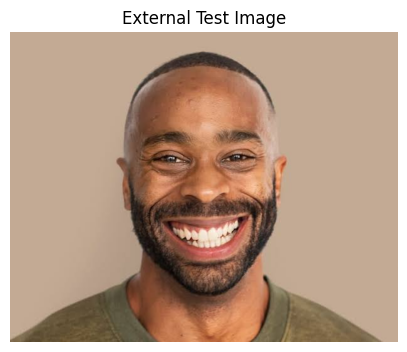

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

# Change this to your uploaded Kaggle image path
real_img_path = "/kaggle/input/datasets/cbinayak70/my-data/happy.jpeg"

real_img = Image.open(real_img_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(real_img)
plt.title("External Test Image")
plt.axis("off")
plt.show()

In [55]:
# CNN and ResNet use 96x96 transforms
real_cnn_input = cnn_test_transform_50(real_img).unsqueeze(0).to(device)
real_resnet_input = resnet_test_transform_50(real_img).unsqueeze(0).to(device)

# EfficientNet uses 224x224 transform
real_eff_input = eff_test_transform_50(real_img).unsqueeze(0).to(device)

print("CNN input:", real_cnn_input.shape)
print("ResNet input:", real_resnet_input.shape)
print("EfficientNet input:", real_eff_input.shape)

CNN input: torch.Size([1, 3, 96, 96])
ResNet input: torch.Size([1, 3, 96, 96])
EfficientNet input: torch.Size([1, 3, 224, 224])


In [57]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

class_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

# Load saved best models
cnn_model_50.load_state_dict(
    torch.load("/kaggle/working/best_cnn_50_50.pth", map_location=device)
)
cnn_model_50.eval()

resnet_model_50.load_state_dict(
    torch.load("/kaggle/working/best_resnet50_50_50.pth", map_location=device)
)
resnet_model_50.eval()

efficientnet_model_50.load_state_dict(
    torch.load("/kaggle/working/best_efficientnet_50_50.pth", map_location=device)
)
efficientnet_model_50.eval()

with torch.no_grad():
    real_cnn_prob = F.softmax(cnn_model_50(real_cnn_input), dim=1).cpu().numpy()[0]
    real_resnet_prob = F.softmax(resnet_model_50(real_resnet_input), dim=1).cpu().numpy()[0]
    real_eff_prob = F.softmax(efficientnet_model_50(real_eff_input), dim=1).cpu().numpy()[0]

In [58]:
eps = 1e-12

# Uses weights found by your weighted DST search
weighted_dst_real_prob = (
    (real_cnn_prob + eps) ** best_w_cnn_dst *
    (real_resnet_prob + eps) ** best_w_resnet_dst *
    (real_eff_prob + eps) ** best_w_eff_dst
)

weighted_dst_real_prob = weighted_dst_real_prob / (
    weighted_dst_real_prob.sum() + eps
)

# Predictions
cnn_prediction = class_names[np.argmax(real_cnn_prob)]
resnet_prediction = class_names[np.argmax(real_resnet_prob)]
eff_prediction = class_names[np.argmax(real_eff_prob)]
weighted_dst_prediction = class_names[np.argmax(weighted_dst_real_prob)]

print("CustomCNN Prediction:", cnn_prediction)
print("ResNet50 Prediction:", resnet_prediction)
print("EfficientNet Prediction:", eff_prediction)
print("Weighted DST Prediction:", weighted_dst_prediction)

print("\nWeighted DST weights used:")
print("CustomCNN weight:", best_w_cnn_dst)
print("ResNet50 weight:", best_w_resnet_dst)
print("EfficientNet weight:", best_w_eff_dst)

CustomCNN Prediction: Disgust
ResNet50 Prediction: Anger
EfficientNet Prediction: Anger
Weighted DST Prediction: Anger

Weighted DST weights used:
CustomCNN weight: 0.8
ResNet50 weight: 0.1
EfficientNet weight: 0.1
